# Naive Bayes — A Step‑by‑Step, From‑Scratch Implementation (with Practical Examples)

**Colab-ready notebook.**  
We will:
1. Build Naive Bayes *from scratch* in pure Python/NumPy.
2. Work through two concrete examples:
   - **Gaussian Naive Bayes** for tabular data (Iris).
   - **Multinomial Naive Bayes** for text (mini spam/ham).
3. Compare to `scikit-learn` to validate correctness and discuss nuances.
4. Reflect on assumptions, smoothing, and model selection.

## Learning Objectives
- Derive the Naive Bayes decision rule from Bayes’ theorem.
- Implement class priors and class‑conditional likelihoods under **feature conditional independence**.
- Implement **Gaussian** and **Multinomial** variants with **log‑probabilities**.
- Understand **Laplace smoothing** and variance smoothing.
- Evaluate with accuracy, confusion matrices, and most informative features.

## Required Imports
Only standard scientific Python libraries are used. No internet access is required.

In [ ]:
import math
import numpy as np
from collections import Counter, defaultdict
import re

# Optional (used to load the Iris dataset and to compare against sklearn implementations)
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.naive_bayes import GaussianNB, MultinomialNB

import matplotlib.pyplot as plt
np.set_printoptions(precision=3, suppress=True)

## A. Gaussian Naive Bayes (From Scratch) on Iris

**Assumption:** For each class $y$ and each feature $x_j$, we assume $x_j \mid y$ is Gaussian with class‑specific mean and variance:
$$ x_j \mid y=c \sim \mathcal{N}(\mu_{c,j}, \sigma^2_{c,j}). $$

Under the Naive Bayes independence assumption:
$$ \log p(x \mid y=c) = \sum_j \log \mathcal{N}(x_j; \mu_{c,j}, \sigma^2_{c,j}). $$

We use **log‑space** to prevent underflow, and we add a small **variance smoothing** term to handle near‑zero variances.

In [ ]:
class GaussianNaiveBayesScratch:
    def __init__(self, var_smoothing=1e-9):
        self.var_smoothing = var_smoothing
        self.classes_ = None
        self.class_priors_log_ = None
        self.means_ = None     # shape: (n_classes, n_features)
        self.vars_ = None      # shape: (n_classes, n_features)

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y)
        self.classes_, counts = np.unique(y, return_counts=True)
        n_classes = len(self.classes_)
        n_features = X.shape[1]

        # Priors
        priors = counts / counts.sum()
        self.class_priors_log_ = np.log(priors)

        # Per-class mean/var
        self.means_ = np.zeros((n_classes, n_features), dtype=float)
        self.vars_  = np.zeros((n_classes, n_features), dtype=float)
        for idx, c in enumerate(self.classes_):
            Xc = X[y == c]
            self.means_[idx] = Xc.mean(axis=0)
            # unbiased var with ddof=0 is fine here; add small smoothing for stability
            self.vars_[idx]  = Xc.var(axis=0) + self.var_smoothing
        return self

    def _log_gaussian_pdf(self, X):
        # X: (n_samples, n_features)
        # returns: (n_classes, n_samples)
        n_samples, n_features = X.shape
        n_classes = self.means_.shape[0]
        log_probs = np.zeros((n_classes, n_samples), dtype=float)
        for k in range(n_classes):
            mu = self.means_[k]
            var = self.vars_[k]
            # log N(x; mu, var) per feature, sum over features
            # log( (2π)^(-d/2) * Π var_j^(-1/2) * exp( -0.5 * Σ (x_j - mu_j)^2 / var_j ) )
            # = -0.5 * Σ [ log(2π var_j) + (x_j - mu_j)^2 / var_j ]
            log_det = -0.5 * np.sum(np.log(2 * np.pi * var))
            quad = -0.5 * np.sum(((X - mu) ** 2) / var, axis=1)
            log_probs[k] = log_det + quad
        return log_probs

    def predict_log_proba(self, X):
        X = np.asarray(X, dtype=float)
        log_likelihood = self._log_gaussian_pdf(X)          # (n_classes, n_samples)
        log_posterior  = (log_likelihood.T + self.class_priors_log_)  # broadcast to (n_samples, n_classes)
        # Normalize (log‑softmax) for numerical niceness
        # subtract max to improve stability
        max_log = np.max(log_posterior, axis=1, keepdims=True)
        log_posterior = log_posterior - max_log - np.log(np.sum(np.exp(log_posterior - max_log), axis=1, keepdims=True))
        return log_posterior

    def predict(self, X):
        X = np.asarray(X, dtype=float)
        log_likelihood = self._log_gaussian_pdf(X)          # (n_classes, n_samples)
        log_posterior  = (log_likelihood.T + self.class_priors_log_)  # (n_samples, n_classes)
        return self.classes_[np.argmax(log_posterior, axis=1)]

### Train/Test on Iris
We'll split Iris into train/test, fit our from‑scratch model, and evaluate.

From‑scratch GaussianNB accuracy: 0.920
Confusion matrix:
 [[16  0  0]
 [ 0 16  1]
 [ 0  3 14]]


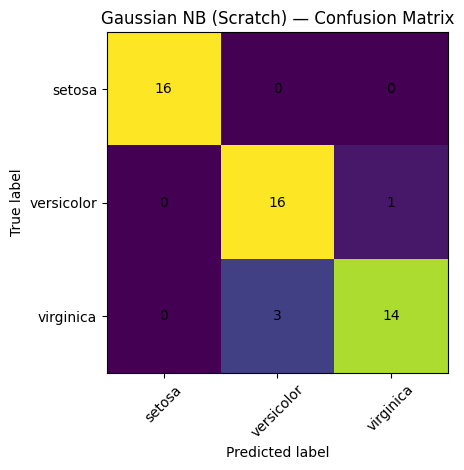

In [ ]:
iris = datasets.load_iris()
X = iris.data
y = iris.target
target_names = iris.target_names

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42, stratify=y)

gnb = GaussianNaiveBayesScratch(var_smoothing=1e-9).fit(X_train, y_train)
y_pred = gnb.predict(X_test)

acc = accuracy_score(y_test, y_pred)
cm  = confusion_matrix(y_test, y_pred)

print(f"From‑scratch GaussianNB accuracy: {acc:.3f}")
print("Confusion matrix:\n", cm)

# Visualize confusion matrix
plt.figure()
plt.imshow(cm, interpolation='nearest')
plt.title('Gaussian NB (Scratch) — Confusion Matrix')
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.xticks(range(len(target_names)), target_names, rotation=45)
plt.yticks(range(len(target_names)), target_names)
for (i, j), v in np.ndenumerate(cm):
    plt.text(j, i, str(v), ha='center', va='center')
plt.tight_layout()
plt.show()

### Compare to scikit‑learn’s `GaussianNB`
This sanity‑checks our implementation.

In [ ]:
sk_gnb = GaussianNB(var_smoothing=1e-9)
sk_gnb.fit(X_train, y_train)
sk_pred = sk_gnb.predict(X_test)

print(f"sklearn GaussianNB accuracy: {accuracy_score(y_test, sk_pred):.3f}")
print("Classification report (sklearn):")
print(classification_report(y_test, sk_pred, target_names=target_names))

sklearn GaussianNB accuracy: 0.920
Classification report (sklearn):
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        16
  versicolor       0.84      0.94      0.89        17
   virginica       0.93      0.82      0.88        17

    accuracy                           0.92        50
   macro avg       0.93      0.92      0.92        50
weighted avg       0.92      0.92      0.92        50



## B. Multinomial Naive Bayes (From Scratch) for Text (Mini Spam/Ham)
The **Multinomial** model assumes word counts (bag‑of‑words). For class $c$ and vocabulary term $w$:
$$ p(w \mid c) = \frac{\text{count}(w,c) + \alpha}{\sum_{w'} \text{count}(w',c) + \alpha \cdot |V|} $$
with **Laplace smoothing** $\alpha > 0$, often $\alpha=1$.

We’ll build a tiny dataset directly in the notebook to keep it self‑contained.

In [ ]:
mini_corpus = [
    # ham
    ("ham",  "Lunch at 12 today?"),
    ("ham",  "Are you coming to the meeting tomorrow?"),
    ("ham",  "Can you send me the report?"),
    ("ham",  "Let’s catch up later this week."),
    ("ham",  "Don’t forget to call mom."),
    ("ham",  "See you at the airport at 6."),
    ("ham",  "Thanks for your help yesterday."),
    ("ham",  "Project update: metrics look good."),
    ("ham",  "Dinner at our place on Friday?"),
    ("ham",  "I booked the conference room."),
    # spam
    ("spam", "WIN money now!!! Click this link for cash prizes."),
    ("spam", "Congratulations—you have been selected for a gift card."),
    ("spam", "Hot investment tip: guaranteed returns, act fast!"),
    ("spam", "Exclusive deal just for you—open immediately."),
    ("spam", "Lowest prices on meds, order without prescription."),
    ("spam", "You won a lottery, claim your reward today."),
    ("spam", "Free vacation package, limited time offer."),
    ("spam", "Open this attachment for your invoice."),
    ("spam", "Act now to avoid account suspension."),
    ("spam", "Cheap loans approved instantly. Apply today."),
]

rng = np.random.default_rng(42)
rng.shuffle(mini_corpus)
labels = np.array([c for c, _ in mini_corpus])
texts  = [t for _, t in mini_corpus]

# Simple split
n = len(texts)
split = int(0.7 * n)
texts_train, texts_test = texts[:split], texts[split:]
y_train_txt, y_test_txt = labels[:split], labels[split:]

def simple_tokenize(s):
    tokens = re.findall(r"[a-zA-Z']+", s.lower())
    return [t for t in tokens if len(t) > 1]  # drop 1-char tokens

### Build a Bag‑of‑Words Vectorizer
We’ll implement a minimal vectorizer yielding word counts for a given vocabulary. This keeps the pipeline fully transparent.

In [ ]:
class MiniCountVectorizer:
    def __init__(self, min_df=1):
        self.vocab_ = {}
        self.min_df = min_df
        self.df_ = Counter()

    def fit(self, texts):
        tokenized = [simple_tokenize(t) for t in texts]
        for toks in tokenized:
            self.df_.update(set(toks))  # document frequency
        # build vocab with min_df filter
        vocab_terms = [t for t, df in self.df_.items() if df >= self.min_df]
        vocab_terms.sort()
        self.vocab_ = {t: i for i, t in enumerate(vocab_terms)}
        return self

    def transform(self, texts):
        rows = []
        for t in texts:
            vec = np.zeros(len(self.vocab_), dtype=int)
            for tok in simple_tokenize(t):
                if tok in self.vocab_:
                    vec[self.vocab_[tok]] += 1
            rows.append(vec)
        return np.vstack(rows)

    def fit_transform(self, texts):
        self.fit(texts)
        return self.transform(texts)

### Multinomial NB (From Scratch)
We compute class priors and per‑class word probabilities with Laplace smoothing. We then score documents with log‑posteriors.

In [ ]:
class MultinomialNaiveBayesScratch:
    def __init__(self, alpha=1.0):
        self.alpha = float(alpha)
        self.classes_ = None
        self.class_log_prior_ = None
        self.feature_log_prob_ = None  # shape: (n_classes, |V|)
        self.vocab_size_ = None

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)  # counts
        y = np.asarray(y)
        self.classes_, counts = np.unique(y, return_counts=True)
        n_classes = len(self.classes_)
        n_features = X.shape[1]
        self.vocab_size_ = n_features

        # Priors
        class_priors = counts / counts.sum()
        self.class_log_prior_ = np.log(class_priors)

        # Count words per class
        class_feature_counts = np.zeros((n_classes, n_features), dtype=float)
        for idx, c in enumerate(self.classes_):
            class_feature_counts[idx] = X[y == c].sum(axis=0)

        # Laplace smoothing
        smoothed = class_feature_counts + self.alpha
        class_totals = smoothed.sum(axis=1, keepdims=True)  # denominator per class
        self.feature_log_prob_ = np.log(smoothed) - np.log(class_totals)
        return self

    def predict_log_proba(self, X):
        X = np.asarray(X, dtype=float)
        # log P(y=c) + sum_i x_i * log P(w_i | c)
        jll = X @ self.feature_log_prob_.T + self.class_log_prior_  # (n_samples, n_classes)
        # normalize for presentation (optional)
        max_log = np.max(jll, axis=1, keepdims=True)
        log_norm = max_log + np.log(np.sum(np.exp(jll - max_log), axis=1, keepdims=True))
        return jll - log_norm

    def predict(self, X):
        X = np.asarray(X, dtype=float)
        jll = X @ self.feature_log_prob_.T + self.class_log_prior_
        return self.classes_[np.argmax(jll, axis=1)]

### Train/Evaluate on the Mini Spam/Ham Corpus

In [ ]:
# Vectorize
vect = MiniCountVectorizer(min_df=1)
X_train_txt = vect.fit_transform(texts_train)
X_test_txt  = vect.transform(texts_test)

mnb = MultinomialNaiveBayesScratch(alpha=1.0).fit(X_train_txt, y_train_txt)
pred_txt = mnb.predict(X_test_txt)

print(f"From‑scratch MultinomialNB accuracy: {accuracy_score(y_test_txt, pred_txt):.3f}")
print("Confusion matrix:")
print(confusion_matrix(y_test_txt, pred_txt))
print("Classification report:")
print(classification_report(y_test_txt, pred_txt))

# Show most informative features (log-odds)
# log P(w|spam) - log P(w|ham)
if set(mnb.classes_) == set(["spam","ham"]):
    idx_spam = np.where(mnb.classes_ == "spam")[0][0]
    idx_ham  = np.where(mnb.classes_ == "ham")[0][0]
    log_odds = mnb.feature_log_prob_[idx_spam] - mnb.feature_log_prob_[idx_ham]
    top_spam = np.argsort(-log_odds)[:10]
    top_ham  = np.argsort(log_odds)[:10]

    inv_vocab = {i:t for t,i in vect.vocab_.items()}
    print("\nTop indicative words for SPAM:")
    for i in top_spam:
        print(f"  {inv_vocab[i]:<15s}  log-odds={log_odds[i]:.3f}")
    print("\nTop indicative words for HAM:")
    for i in top_ham:
        print(f"  {inv_vocab[i]:<15s}  log-odds={log_odds[i]:.3f}")

From‑scratch MultinomialNB accuracy: 0.667
Confusion matrix:
[[3 1]
 [1 1]]
Classification report:
              precision    recall  f1-score   support

         ham       0.75      0.75      0.75         4
        spam       0.50      0.50      0.50         2

    accuracy                           0.67         6
   macro avg       0.62      0.62      0.62         6
weighted avg       0.67      0.67      0.67         6


Top indicative words for SPAM:
  act              log-odds=0.862
  now              log-odds=0.862
  apply            log-odds=0.456
  account          log-odds=0.456
  been             log-odds=0.456
  avoid            log-odds=0.456
  cash             log-odds=0.456
  approved         log-odds=0.456
  click            log-odds=0.456
  cheap            log-odds=0.456

Top indicative words for HAM:
  at               log-odds=-1.623
  the              log-odds=-1.336
  catch            log-odds=-0.930
  airport          log-odds=-0.930
  conference       log-odds=-0.

### Compare to scikit‑learn’s `MultinomialNB`

In [ ]:
sk_mnb = MultinomialNB(alpha=1.0)
sk_mnb.fit(X_train_txt, y_train_txt)
sk_pred_txt = sk_mnb.predict(X_test_txt)

print(f"sklearn MultinomialNB accuracy: {accuracy_score(y_test_txt, sk_pred_txt):.3f}")
print("Classification report (sklearn):")
print(classification_report(y_test_txt, sk_pred_txt))

sklearn MultinomialNB accuracy: 0.667
Classification report (sklearn):
              precision    recall  f1-score   support

         ham       0.75      0.75      0.75         4
        spam       0.50      0.50      0.50         2

    accuracy                           0.67         6
   macro avg       0.62      0.62      0.62         6
weighted avg       0.67      0.67      0.67         6



## Discussion: Assumptions, Strengths, and Pitfalls

- **Conditional independence** is rarely literally true, but NB often works well in high‑dimensional sparse settings (e.g., text).
- **Gaussian vs Multinomial vs Bernoulli**: pick based on feature type (continuous, counts, binary presence).
- **Smoothing**:
  - *Multinomial*: Laplace/Dirichlet smoothing ($\alpha$) prevents zero probabilities and combats overfitting.
  - *Gaussian*: variance smoothing avoids division by ~0; one may also regularize variances or tie them across classes.
- **Calibration**: NB posteriors can be poorly calibrated; consider Platt scaling / isotonic regression if calibrated probabilities matter.
- **Feature engineering**: stop‑word removal, n‑grams, TF‑IDF, and preprocessing can significantly impact text performance.
- **Model comparison**: While linear SVMs/logistic regression often outperform NB on text, NB remains fast, robust, and competitive—excellent as a baseline.

## Exercises (Optional)

1. **Bernoulli NB**: Implement a Bernoulli variant using binary word presence instead of counts. Compare to Multinomial.
2. **TF‑IDF**: Swap the count vectorizer for TF‑IDF features and observe how performance changes (note: strictly, Multinomial NB expects counts; consider Gaussian NB for TF‑IDF).
3. **Hyperparameters**: Sweep $\alpha$ for the text model and observe bias‑variance trade‑offs.
4. **Robustness**: Add spelling noise to the test texts and analyze degradation.
5. **Explainability**: For Iris, visualize 2D decision boundaries by selecting two features at a time.